In [7]:
from pytrends.request import TrendReq
import pandas as pd

In [8]:
# connect to google trends
pytrends = TrendReq(hl = 'en-US' , tz = 330)

In [9]:

# keywords
keywords = ["ChatGPT" , "Bitcoin", "World Cup"]

In [10]:
# fetch data
pytrends.build_payload(keywords , timeframe = 'today 12-m')
data = pytrends.interest_over_time()

In [11]:
# clean
data = data.drop(columns = ['isPartial'])

In [12]:

print(data.head())

            ChatGPT  Bitcoin  World Cup
date                                   
2025-07-06       19        2          3
2025-07-13       20        2          2
2025-07-20       21        2          1
2025-07-27       21        2          1
2025-08-03       24        2          1


In [13]:
#save dataset
data.to_csv("trends.csv")

In [14]:
import pandas as pd

data = pd.read_csv("trends.csv" , index_col = 0)
data.index = pd.to_datetime(data.index)

print(data.head())

            ChatGPT  Bitcoin  World Cup
date                                   
2025-07-06       19        2          3
2025-07-13       20        2          2
2025-07-20       21        2          1
2025-07-27       21        2          1
2025-08-03       24        2          1


In [15]:
data_smooth = data.rolling(window = 7).mean()

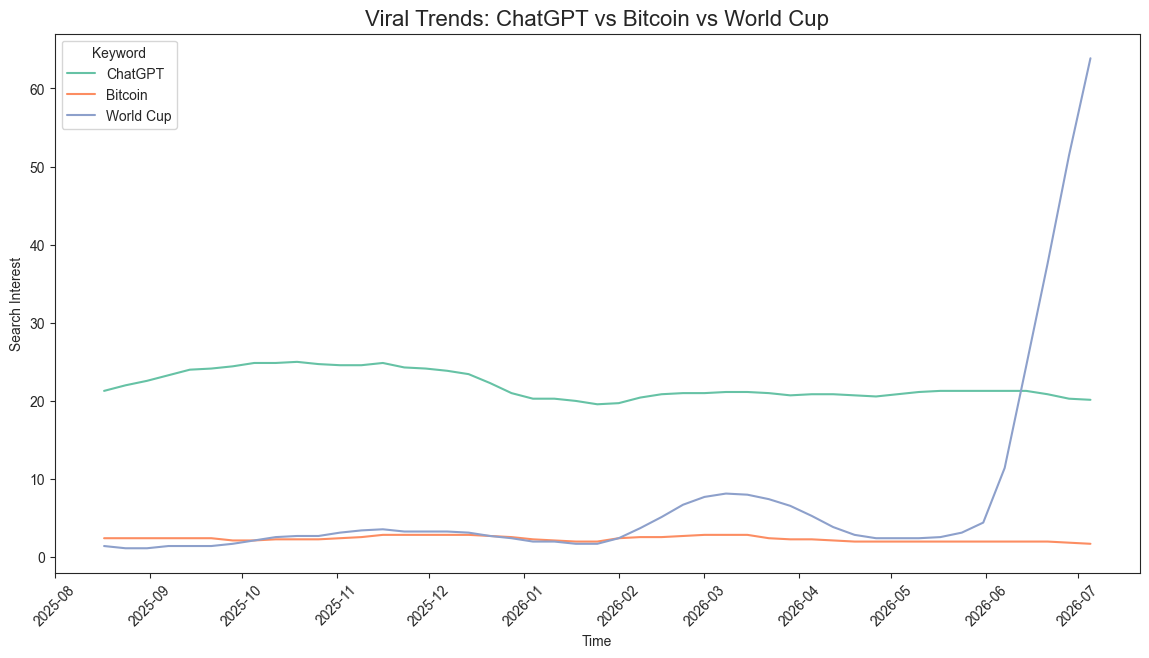

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# reset index so date becomes a column
df = data_smooth.reset_index()
#convert wide -> long
df_long = df.melt(id_vars='date' , var_name = 'Keyword' , value_name='Interest')

plt.figure(figsize=(14,7))

sns.lineplot(data=df_long , x = 'date' , y = 'Interest' , hue = 'Keyword')

plt.title("Viral Trends: ChatGPT vs Bitcoin vs World Cup", fontsize=16)
plt.xlabel("Time")
plt.ylabel("Search Interest")
plt.xticks(rotation=45)

sns.set_style("whitegrid")

plt.show()